# AKI Prediction from MIMIC-III — Local Run

Predict Acute Kidney Injury (AKI) from early ICU labs and demographics using MIMIC-III.

**Prerequisites**
- Python packages: `pandas`, `numpy`, `scikit-learn` (optionally `xgboost`)
- MIMIC-III CSV files already extracted to a local folder:
  - `patients.csv`, `admissions.csv`, `icustays.csv`, `labevents.csv`


## Step 1 — Imports


In [15]:
import os
import time
import warnings
import numpy as np
import pandas as pd

# Use non-interactive backend when running as a plain script (outside Jupyter)
import matplotlib
try:
    get_ipython()                       # defined inside Jupyter/IPython kernels
    # Jupyter sets its own backend automatically — do nothing
except NameError:
    matplotlib.use("Agg")               # script mode: save to file, no window

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    classification_report, confusion_matrix,
    roc_curve,
)

warnings.filterwarnings("ignore")

# Slide-friendly style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})

VERBOSE = False   # set True for full classification reports

try:
    import xgboost as xgb
    HAS_XGB = True
    print("XGBoost available")
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — will skip it (LogReg + RF still run)")

print("Imports OK")

XGBoost available
Imports OK


## Step 2 — Configuration

Set `DATA_DIR` to the folder that contains your four CSV files.  
Adjust `SUBSET_N_STAYS` to control RAM/time (lower = faster; `None` = use all data).

In [16]:
# ── Change this to your CSV folder ──────────────────────────────────────────
DATA_DIR = r"f:\lotus\Documents\New folder (2)"
# ────────────────────────────────────────────────────────────────────────────

SUBSET_N_STAYS = None    # use all ICU stays in the dataset (~15–30 min, needs 6–8 GB RAM)
USE_LOW_MEMORY = True    # chunk-read labevents.csv (keeps RAM low on 8 GB machines)
TRACK_PROGRESS = True    # print timing for each step

REQUIRED = ["patients.csv", "admissions.csv", "icustays.csv", "labevents.csv"]
missing = [f for f in REQUIRED if not os.path.exists(os.path.join(DATA_DIR, f))]

T_START = time.time()

if missing:
    print("ERROR: missing files:", missing)
    print("Set DATA_DIR to the folder containing", REQUIRED)
else:
    n_label = str(SUBSET_N_STAYS) if SUBSET_N_STAYS else "ALL"
    print(f"Config OK  |  DATA_DIR: {DATA_DIR}  |  SUBSET_N_STAYS: {n_label}")

Config OK  |  DATA_DIR: f:\lotus\Documents\New folder (2)  |  SUBSET_N_STAYS: ALL


## Step 3 — Load MIMIC-III tables

Reads `patients`, `admissions`, `icustays`, and `labevents` from `DATA_DIR`.
- Works with both **UPPERCASE** and lowercase column names (your files use UPPERCASE).
- `patients.csv` has `DOB` instead of `anchor_age` — age is computed from DOB + first ICU intime.
- `labevents.csv` is streamed in 400k-row chunks and filtered to the 6 lab item IDs used in this project.

> **This step takes the longest** (several minutes for 15 k stays). You will see chunk progress every 5 chunks.

In [17]:
# Lab item IDs needed (creatinine for AKI + 5 labs for features)
LAB_ITEMIDS_SET = {50912, 50971, 50824, 50882, 51006, 51221}
# 50912 = creatinine, 50971 = potassium, 50824 = sodium,
# 50882 = bicarbonate, 51006 = BUN, 51221 = hemoglobin

def _lower(df):
    """Rename all columns to lowercase so the rest of the code is case-insensitive."""
    return df.rename(columns=str.lower)

def _usecols(path, want):
    """Return the actual column names in `path` that match the wanted lowercase names."""
    header = pd.read_csv(path, nrows=0).columns.tolist()
    low    = [c.lower() for c in header]
    return [header[i] for i, c in enumerate(low) if c in want]

def load_tables(data_dir, low_memory=True, subset_n=None, progress=False):
    # ── patients ──────────────────────────────────────────────────────────────
    p_path = os.path.join(data_dir, "patients.csv")
    p_header = pd.read_csv(p_path, nrows=0).columns.tolist()
    p_lower  = [c.lower() for c in p_header]

    if "anchor_age" in p_lower:
        # MIMIC-IV style: has anchor_age directly
        cols = _usecols(p_path, {"subject_id", "gender", "anchor_age", "anchor_year"})
        patients = _lower(pd.read_csv(p_path, usecols=cols))
    else:
        # MIMIC-III style: has DOB — age computed below
        cols = _usecols(p_path, {"subject_id", "gender", "dob"})
        dob_col = p_header[p_lower.index("dob")]
        patients = _lower(pd.read_csv(p_path, usecols=cols, parse_dates=[dob_col]))

    # ── admissions ────────────────────────────────────────────────────────────
    a_path = os.path.join(data_dir, "admissions.csv")
    a_head  = pd.read_csv(a_path, nrows=0).columns.tolist()
    a_lower = [c.lower() for c in a_head]
    a_cols  = _usecols(a_path, {"subject_id", "hadm_id", "admittime", "dischtime", "ethnicity"})
    a_dates = [a_head[a_lower.index("admittime")], a_head[a_lower.index("dischtime")]]
    admissions = _lower(pd.read_csv(a_path, usecols=a_cols, parse_dates=a_dates))

    # ── icustays ──────────────────────────────────────────────────────────────
    i_path = os.path.join(data_dir, "icustays.csv")
    i_head  = pd.read_csv(i_path, nrows=0).columns.tolist()
    i_lower = [c.lower() for c in i_head]
    i_cols  = _usecols(i_path, {"subject_id", "hadm_id", "icustay_id", "intime", "outtime", "los"})
    i_dates = [i_head[i_lower.index("intime")], i_head[i_lower.index("outtime")]]
    icustays = _lower(pd.read_csv(i_path, usecols=i_cols, parse_dates=i_dates))

    # ── compute age from DOB if needed ────────────────────────────────────────
    if "anchor_age" not in patients.columns and "dob" in patients.columns:
        first_intime = icustays.groupby("subject_id")["intime"].min().reset_index()
        patients = patients.merge(first_intime, on="subject_id", how="left")
        patients["anchor_age"] = (
            patients["intime"].dt.year - patients["dob"].dt.year
        ).clip(0, 120).fillna(0).astype(int)
        patients = patients.drop(columns=["intime"])

    # ── subset ICU stays ──────────────────────────────────────────────────────
    subset_df = None
    if subset_n is not None and subset_n > 0:
        n = min(int(subset_n), len(icustays))
        icustays = icustays.sample(n=n, random_state=42)
        subset_df = icustays[["subject_id", "hadm_id"]].drop_duplicates()
        patients   = patients[patients["subject_id"].isin(icustays["subject_id"])]
        admissions = admissions[admissions["hadm_id"].isin(icustays["hadm_id"])]

    # ── labevents (stream in chunks, filter to needed item IDs + subset) ──────
    l_path  = os.path.join(data_dir, "labevents.csv")
    l_head  = pd.read_csv(l_path, nrows=0).columns.tolist()
    l_lower = [c.lower() for c in l_head]
    l_cols  = _usecols(l_path, {"subject_id", "hadm_id", "charttime", "itemid", "valuenum"})
    l_dates = [l_head[l_lower.index("charttime")]]
    l_item  = l_head[l_lower.index("itemid")]   # original-case itemid column name

    chunks, n_chunk = [], 0
    for chunk in pd.read_csv(l_path, usecols=l_cols, parse_dates=l_dates,
                              dtype={l_item: int}, chunksize=400_000):
        n_chunk += 1
        if progress and n_chunk % 5 == 0:
            print(f"  reading labevents chunk {n_chunk}...")
        chunk = _lower(chunk)
        chunk = chunk.dropna(subset=["valuenum"])
        chunk = chunk[chunk["itemid"].isin(LAB_ITEMIDS_SET)]
        if subset_df is not None:
            chunk = chunk.merge(subset_df, on=["subject_id", "hadm_id"], how="inner")
        chunks.append(chunk)
    labevents = pd.concat(chunks, ignore_index=True)

    return patients, admissions, icustays, labevents


t0 = time.time()
patients, admissions, icustays, labevents = load_tables(
    DATA_DIR, low_memory=USE_LOW_MEMORY, subset_n=SUBSET_N_STAYS, progress=TRACK_PROGRESS
)
print("[1/6] Load: %d patients, %d stays, %d lab rows  (%.1f min)"
      % (len(patients), len(icustays), len(labevents), (time.time() - t0) / 60))

  reading labevents chunk 5...
  reading labevents chunk 10...
  reading labevents chunk 15...
  reading labevents chunk 20...
  reading labevents chunk 25...
  reading labevents chunk 30...
  reading labevents chunk 35...
  reading labevents chunk 40...
  reading labevents chunk 45...
  reading labevents chunk 50...
  reading labevents chunk 55...
  reading labevents chunk 60...
  reading labevents chunk 65...
  reading labevents chunk 70...
[1/6] Load: 46520 patients, 61532 stays, 4167975 lab rows  (0.5 min)


## Step 4 — Cohort + AKI labels

**Cohort filters** applied to ICU stays:
- Age ≥ 18
- First ICU stay per hospital admission
- ICU length of stay ≥ 24 h
- At least 2 creatinine values in the first 7 days

**AKI label (KDIGO-style)** — `aki = 1` if either:
- SCr rises ≥ 0.3 mg/dL within 48 h of ICU admission, OR
- SCr reaches ≥ 1.5 × baseline within 7 days (baseline = first creatinine in first 48 h)

In [4]:
t0 = time.time()
CREATININE_ID = 50912   # MIMIC-III labevents itemid for serum creatinine

# ── creatinine subset ─────────────────────────────────────────────────────────
creat = (
    labevents[labevents["itemid"] == CREATININE_ID]
    .copy()
    .rename(columns={"valuenum": "creatinine"})
    [["subject_id", "hadm_id", "charttime", "creatinine"]]
)

# ── cohort filters ────────────────────────────────────────────────────────────
stays = icustays.merge(patients[["subject_id", "anchor_age"]], on="subject_id", how="inner")
stays = stays[stays["anchor_age"] >= 18]                              # adults only
stays = (stays.sort_values(["hadm_id", "intime"])                     # first stay per admission
              .groupby("hadm_id").first().reset_index())
stays = stays[stays["los"] >= 1.0]                                    # at least 24 h in ICU

# ── align creatinine to ICU admission time ────────────────────────────────────
creat = creat.merge(stays[["subject_id", "hadm_id", "icustay_id", "intime"]],
                    on=["subject_id", "hadm_id"], how="inner")
creat["hours_from_icu"] = (creat["charttime"] - creat["intime"]).dt.total_seconds() / 3600
creat = creat[(creat["hours_from_icu"] >= 0) & (creat["hours_from_icu"] <= 7 * 24)]

# ── baseline creatinine (first value in first 48 h) ───────────────────────────
creat_48h = creat[creat["hours_from_icu"] <= 48].sort_values("charttime")
baseline = creat_48h.groupby("icustay_id").agg(
    baseline_creat=("creatinine", "first"),
    baseline_time=("charttime",   "first"),
).reset_index()

# ── require ≥ 2 creatinine values in 7 d ─────────────────────────────────────
n_creat = creat.groupby("icustay_id").size().rename("n_creat")
stays = (stays.merge(baseline, on="icustay_id", how="inner")
              .merge(n_creat,  on="icustay_id", how="inner"))
stays = stays[stays["n_creat"] >= 2]

# ── KDIGO AKI rule (applied per row) ─────────────────────────────────────────
def has_aki(row):
    icu, base = row["icustay_id"], row["baseline_creat"]
    c = creat[creat["icustay_id"] == icu]
    if (c["creatinine"] >= 1.5 * base).any():          # 1.5× rise within 7 d
        return 1
    c48 = c[c["hours_from_icu"] <= 48]
    if (c48["creatinine"] >= base + 0.3).any():         # ≥0.3 rise within 48 h
        return 1
    return 0

stays["aki"] = stays.apply(has_aki, axis=1)

cohort = stays[["subject_id", "hadm_id", "icustay_id",
                "intime", "outtime", "los",
                "anchor_age", "baseline_creat", "aki"]].copy()

print("[2/6] Cohort: %d stays, AKI prevalence %.1f%%  (%.1f min)"
      % (len(cohort), 100 * cohort["aki"].mean(), (time.time() - t0) / 60))

[2/6] Cohort: 40752 stays, AKI prevalence 22.0%  (1.1 min)


## Step 5 — Feature extraction

Features built per ICU stay from the **first 24 hours**:

| Group | Features |
|-------|----------|
| Demographics | age, gender (0/1) |
| Creatinine | min, max, mean |
| Potassium | min, max, mean |
| Sodium | min, max, mean |
| Bicarbonate | min, max, mean |
| BUN | min, max, mean |
| Hemoglobin | min, max, mean |

Missing lab values are imputed with the **cohort median** (per column).

In [5]:
t0 = time.time()

LAB_NAMES = {
    50912: "creatinine",
    50971: "potassium",
    50824: "sodium",
    50882: "bicarbonate",
    51006: "bun",
    51221: "hemoglobin",
}

# ── filter to first 24 h of each ICU stay ────────────────────────────────────
lab_feat = labevents[labevents["itemid"].isin(LAB_NAMES)].copy()
lab_feat = lab_feat.merge(
    cohort[["subject_id", "hadm_id", "icustay_id", "intime"]],
    on=["subject_id", "hadm_id"], how="inner"
)
lab_feat["hours_from_icu"] = (
    lab_feat["charttime"] - lab_feat["intime"]
).dt.total_seconds() / 3600
lab_feat = lab_feat[(lab_feat["hours_from_icu"] >= 0) & (lab_feat["hours_from_icu"] <= 24)]
lab_feat["lab_name"] = lab_feat["itemid"].map(LAB_NAMES)

# ── aggregate: min / max / mean per (stay, lab) ───────────────────────────────
agg = (
    lab_feat.groupby(["icustay_id", "lab_name"])["valuenum"]
    .agg(["min", "max", "mean"])
    .reset_index()
)
# pivot to wide: creatinine_min, creatinine_max, creatinine_mean, ...
agg_wide = agg.set_index(["icustay_id", "lab_name"]).unstack(level=1)
agg_wide.columns = [f"{lab}_{stat}" for stat, lab in agg_wide.columns]
agg_wide = agg_wide.reset_index()

# ── demographics ─────────────────────────────────────────────────────────────
demo = cohort[["icustay_id", "subject_id", "anchor_age"]].merge(
    patients[["subject_id", "gender"]], on="subject_id", how="left"
)
demo["gender"] = (demo["gender"] == "M").astype(int)   # 1 = male, 0 = female
demo = demo[["icustay_id", "anchor_age", "gender"]]

# ── assemble feature matrix ───────────────────────────────────────────────────
X_df = (
    cohort[["icustay_id", "aki"]]
    .merge(demo,      on="icustay_id", how="left")
    .merge(agg_wide,  on="icustay_id", how="left")
)

# impute missing with column median
feature_cols = [c for c in X_df.columns if c not in ("icustay_id", "aki")]
for col in feature_cols:
    if X_df[col].isna().any():
        X_df[col] = X_df[col].fillna(X_df[col].median())

y = X_df["aki"].values
X = X_df[feature_cols].astype(float)

print("[3/6] Features: shape=%s, %d feature columns  (%.1f min)"
      % (X.shape, len(feature_cols), (time.time() - t0) / 60))

[3/6] Features: shape=(40752, 20), 20 feature columns  (0.0 min)


## Step 6 — Train / Validation / Test split

Split by **patient** (`subject_id`) to avoid data leakage (same patient cannot appear in both train and test).  
Ratio: **70% train / 15% val / 15% test**.  
Features are standardized (mean=0, std=1) fitted on train only.

In [6]:
# get subject_id aligned to each row in X
subj = X_df.merge(cohort[["icustay_id", "subject_id"]], on="icustay_id", how="left")["subject_id"]

unique_subj = subj.unique()
train_s, rest_s = train_test_split(unique_subj, test_size=0.3, random_state=42)
val_s,   test_s = train_test_split(rest_s,       test_size=0.5, random_state=42)

tr_idx = np.where(subj.isin(train_s))[0]
va_idx = np.where(subj.isin(val_s))[0]
te_idx = np.where(subj.isin(test_s))[0]

X_train, X_val, X_test = X.iloc[tr_idx], X.iloc[va_idx], X.iloc[te_idx]
y_train, y_val, y_test = y[tr_idx],       y[va_idx],       y[te_idx]

scaler   = StandardScaler()
Xtr_s    = scaler.fit_transform(X_train)
Xva_s    = scaler.transform(X_val)
Xte_s    = scaler.transform(X_test)

print("[4/6] Split — train: %d  val: %d  test: %d  |  AKI rate: train=%.1f%%  test=%.1f%%"
      % (len(y_train), len(y_val), len(y_test),
         100 * y_train.mean(), 100 * y_test.mean()))

[4/6] Split — train: 28554  val: 6092  test: 6106  |  AKI rate: train=22.0%  test=21.8%


## Step 7 — Train models

Three models are trained (XGBoost only if installed):

| Model | Notes |
|-------|-------|
| Logistic Regression | Baseline; interpretable; fast |
| Random Forest | Non-linear; gives feature importances |
| XGBoost | Usually strongest; optional |

`class_weight="balanced"` / `scale_pos_weight` handles AKI class imbalance.

In [7]:
models = {}

# ── Logistic Regression ───────────────────────────────────────────────────────
t0 = time.time()
models["Logistic Regression"] = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=42
).fit(Xtr_s, y_train)
t_lr = time.time() - t0

# ── Random Forest ─────────────────────────────────────────────────────────────
t0 = time.time()
models["Random Forest"] = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1
).fit(Xtr_s, y_train)
t_rf = time.time() - t0

# ── XGBoost (optional) ────────────────────────────────────────────────────────
t_xgb = 0
if HAS_XGB:
    t0 = time.time()
    spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    models["XGBoost"] = xgb.XGBClassifier(
        n_estimators=100, max_depth=6, scale_pos_weight=spw,
        use_label_encoder=False, eval_metric="logloss", random_state=42
    ).fit(Xtr_s, y_train)
    t_xgb = time.time() - t0

msg = "[5/6] Train — LogReg: %.0fs  RF: %.0fs" % (t_lr, t_rf)
if HAS_XGB:
    msg += "  XGB: %.0fs" % t_xgb
print(msg)

[5/6] Train — LogReg: 1s  RF: 1s  XGB: 0s


## Step 8 — Evaluate on test set

Reports **AUC-ROC** and **F1** for each model.  
Set `VERBOSE = True` in Step 1 to also print full classification reports and confusion matrices.

In [8]:
def evaluate(name, model, X_te, y_te, verbose=False):
    proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_te)
    pred  = (proba >= 0.5).astype(int)
    auc   = roc_auc_score(y_te, proba) if len(np.unique(y_te)) > 1 else 0.0
    f1    = f1_score(y_te, pred, zero_division=0)
    acc   = accuracy_score(y_te, pred)
    if verbose:
        print(f"\n{'='*40}\n{name}\n{'='*40}")
        print(classification_report(y_te, pred, target_names=["No AKI", "AKI"], zero_division=0))
        print("Confusion matrix:\n", confusion_matrix(y_te, pred))
    return {"auc": auc, "f1": f1, "accuracy": acc}

results = {}
print("[6/6] Test set results:")
print(f"  {'Model':<22} {'AUC':>6}  {'F1':>6}  {'Acc':>6}")
print(f"  {'-'*22} {'-'*6}  {'-'*6}  {'-'*6}")
for name, mdl in models.items():
    r = evaluate(name, mdl, Xte_s, y_test, verbose=VERBOSE)
    results[name] = r
    print(f"  {name:<22} {r['auc']:>6.3f}  {r['f1']:>6.3f}  {r['accuracy']:>6.3f}")

print("\nDone. Total elapsed: %.1f min" % ((time.time() - T_START) / 60))

[6/6] Test set results:
  Model                     AUC      F1     Acc
  ---------------------- ------  ------  ------
  Logistic Regression     0.739   0.489   0.717
  Random Forest           0.771   0.519   0.759
  XGBoost                 0.765   0.524   0.759

Done. Total elapsed: 1.8 min


## Step 9 — Feature importance (Random Forest)

Which early labs and demographics are most predictive of AKI?

In [9]:
rf  = models["Random Forest"]
imp = (
    pd.DataFrame({"feature": feature_cols, "importance": rf.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
print("Top 10 features (Random Forest):")
print(imp.head(10).to_string(index=False))

Top 10 features (Random Forest):
        feature  importance
 creatinine_max    0.149657
creatinine_mean    0.114476
 creatinine_min    0.080460
    sodium_mean    0.072042
 hemoglobin_min    0.056432
  potassium_max    0.055513
     sodium_max    0.053528
     sodium_min    0.046558
     anchor_age    0.043977
        bun_max    0.043327


## Step 10 — Visualization: AKI Prevalence

Class distribution of the cohort — how many stays developed AKI vs did not.

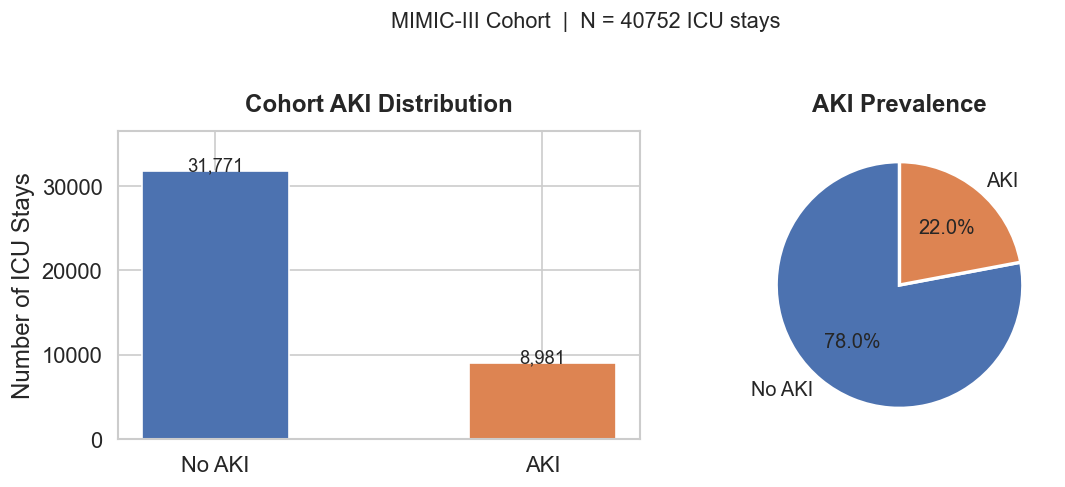

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# ── Bar chart ─────────────────────────────────────────────────────────────────
counts = cohort["aki"].value_counts().sort_index()
labels = ["No AKI", "AKI"]
colors = ["#4C72B0", "#DD8452"]
axes[0].bar(labels, counts.values, color=colors, width=0.45, edgecolor="white")
axes[0].set_title("Cohort AKI Distribution", fontweight="bold", pad=12)
axes[0].set_ylabel("Number of ICU Stays")
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
                 f"{val:,}", ha="center", fontsize=11)
axes[0].set_ylim(0, counts.max() * 1.15)

# ── Pie chart ─────────────────────────────────────────────────────────────────
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2},
            textprops={"fontsize": 12})
axes[1].set_title("AKI Prevalence", fontweight="bold", pad=12)

plt.suptitle("MIMIC-III Cohort  |  N = %d ICU stays" % len(cohort), y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("viz_1_aki_prevalence.png")
plt.show()

## Step 11 — Visualization: ROC Curves

ROC curves for all trained models. AUC closer to 1.0 = better discrimination between AKI and No AKI.

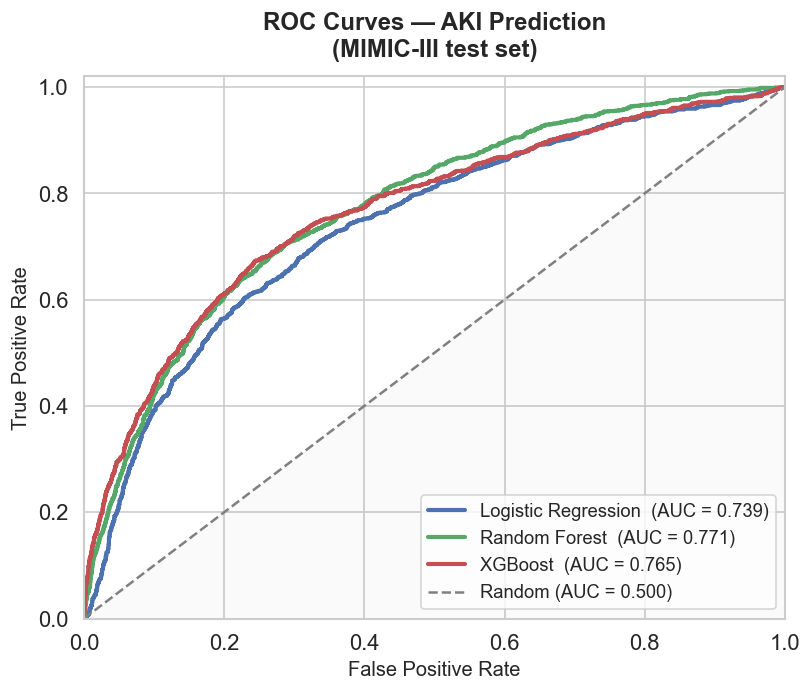

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))

model_colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
for (name, mdl), color in zip(models.items(), model_colors):
    proba = mdl.predict_proba(Xte_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, lw=2.5, color=color, label=f"{name}  (AUC = {auc:.3f})")

# Random baseline
ax.plot([0, 1], [0, 1], linestyle="--", lw=1.5, color="gray", label="Random (AUC = 0.500)")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — AKI Prediction\n(MIMIC-III test set)", fontweight="bold", pad=12)
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.fill_between([0, 1], [0, 1], alpha=0.04, color="gray")

plt.tight_layout()
plt.savefig("viz_2_roc_curves.png")
plt.show()

## Step 12 — Visualization: Feature Importance

Top 10 predictors from Random Forest — shows which early labs and demographics matter most for AKI prediction.

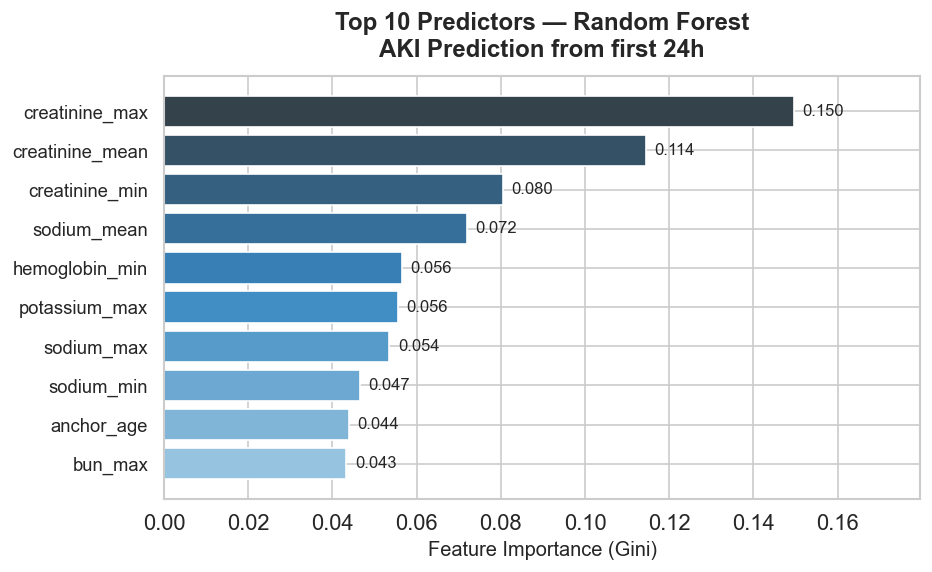

In [12]:
top_n = 10
imp_top = imp.head(top_n).sort_values("importance")   # ascending for horizontal bar

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(imp_top["feature"], imp_top["importance"],
               color=sns.color_palette("Blues_d", top_n), edgecolor="white")

# Value labels on bars
for bar, val in zip(bars, imp_top["importance"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10)

ax.set_xlabel("Feature Importance (Gini)", fontsize=12)
ax.set_title("Top 10 Predictors — Random Forest\nAKI Prediction from first 24h", fontweight="bold", pad=12)
ax.set_xlim(0, imp_top["importance"].max() * 1.2)
ax.tick_params(axis="y", labelsize=11)

plt.tight_layout()
plt.savefig("viz_3_feature_importance.png")
plt.show()

## Step 13 — Visualization: Lab Distributions (AKI vs No AKI)

Box plots comparing the top 4 labs in the first 24h between AKI and No AKI patients. AKI patients tend to have elevated creatinine and lower hemoglobin early on.

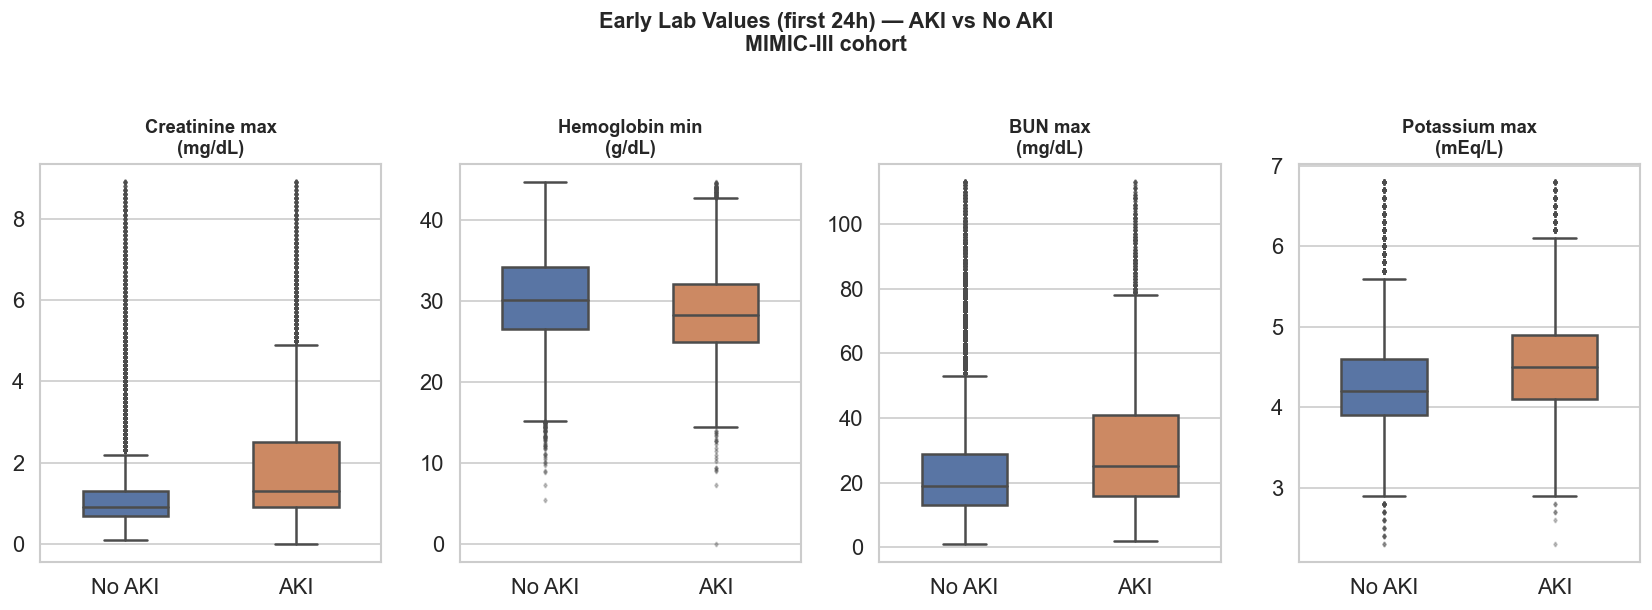

In [13]:
# Top 4 labs to compare (use mean value columns from X_df)
plot_features = ["creatinine_max", "hemoglobin_min", "bun_max", "potassium_max"]
plot_labels   = ["Creatinine max\n(mg/dL)", "Hemoglobin min\n(g/dL)", "BUN max\n(mg/dL)", "Potassium max\n(mEq/L)"]

plot_df = X_df[["aki"] + plot_features].copy()
plot_df["AKI"] = plot_df["aki"].map({0: "No AKI", 1: "AKI"})

fig, axes = plt.subplots(1, 4, figsize=(14, 5))
palette = {"No AKI": "#4C72B0", "AKI": "#DD8452"}

for ax, feat, label in zip(axes, plot_features, plot_labels):
    # clip extreme outliers for readability
    q99 = plot_df[feat].quantile(0.99)
    sub = plot_df[plot_df[feat] <= q99]
    sns.boxplot(data=sub, x="AKI", y=feat, palette=palette,
                order=["No AKI", "AKI"], ax=ax,
                width=0.5, flierprops={"markersize": 2, "alpha": 0.3})
    ax.set_title(label, fontweight="bold", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle("Early Lab Values (first 24h) — AKI vs No AKI\nMIMIC-III cohort",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("viz_4_lab_distributions.png")
plt.show()

## Step 14 — Visualization: Model Comparison + Confusion Matrix

Side-by-side bar chart comparing all models by AUC and F1, plus the confusion matrix for the best model (Random Forest).

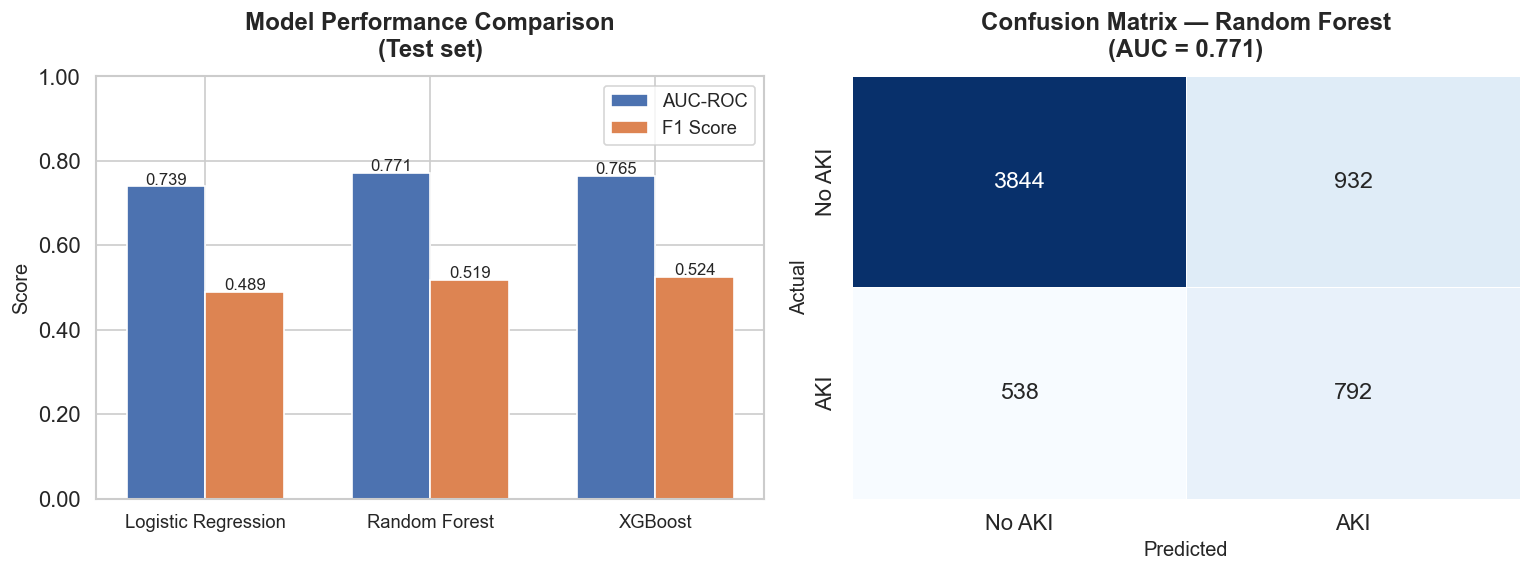

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Model comparison bar chart ────────────────────────────────────────────────
model_names = list(results.keys())
aucs = [results[m]["auc"] for m in model_names]
f1s  = [results[m]["f1"]  for m in model_names]

x = np.arange(len(model_names))
w = 0.35
bars1 = axes[0].bar(x - w/2, aucs, w, label="AUC-ROC", color="#4C72B0", edgecolor="white")
bars2 = axes[0].bar(x + w/2, f1s,  w, label="F1 Score", color="#DD8452", edgecolor="white")

for bars in [bars1, bars2]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                     f"{bar.get_height():.3f}", ha="center", fontsize=10)

axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, fontsize=11)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Score", fontsize=12)
axes[0].set_title("Model Performance Comparison\n(Test set)", fontweight="bold", pad=12)
axes[0].legend(fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

# ── Confusion matrix (best model = Random Forest) ─────────────────────────────
best_name = max(results, key=lambda m: results[m]["auc"])
best_mdl  = models[best_name]
proba_best = best_mdl.predict_proba(Xte_s)[:, 1]
pred_best  = (proba_best >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred_best)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["No AKI", "AKI"], yticklabels=["No AKI", "AKI"],
            linewidths=0.5, cbar=False, annot_kws={"size": 14})
axes[1].set_xlabel("Predicted", fontsize=12)
axes[1].set_ylabel("Actual",    fontsize=12)
axes[1].set_title(f"Confusion Matrix — {best_name}\n(AUC = {results[best_name]['auc']:.3f})",
                  fontweight="bold", pad=12)

plt.tight_layout()
plt.savefig("viz_5_model_comparison.png")
plt.show()

## Step 10 — Summary and limitations

**What was done**
- Loaded MIMIC-III CSV files locally (no Colab, no cloud).
- Built a cohort of ICU patients with KDIGO-style AKI labels from creatinine trends.
- Extracted first-24h lab features (min/max/mean) + demographics.
- Trained Logistic Regression, Random Forest, and optionally XGBoost with patient-level splits.

**Limitations**
- AKI defined by creatinine only — no urine output (KDIGO also uses urine).
- Age from DOB is approximate (MIMIC-III dates are shifted for de-identification).
- Single-center dataset; results may not generalize.
- Not for clinical use.

**Possible extensions**
- Add vitals from `chartevents.csv` (heart rate, BP, SpO₂).
- Extend feature window from 24 h to 48 h.
- Try an MLP or LSTM for sequential modeling.
- Use SHAP for model explainability.